# Notebook 3: Baseline CNN Model

This notebook develops the first deep-learning model for Rice Guard.

Main tasks:

- Load the prepared dataset splits
- Recreate the preprocessing pipeline
- Build a baseline Convolutional Neural Network
- Train and validate the model
- Save the best-performing checkpoint
- Evaluate the model on the internal test set

In [1]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# Set the random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Random seed:", SEED)

Random seed: 42


In [3]:
# Select the training device
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", DEVICE)

Training device: cpu


In [4]:
# Define project paths
PROJECT_ROOT = Path("C:/Projects/16_Rice_Guard")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = PROCESSED_DIR / "train_metadata.csv"
VALIDATION_CSV = PROCESSED_DIR / "validation_metadata.csv"
TEST_CSV = PROCESSED_DIR / "test_metadata.csv"

LABEL_MAPPING_PATH = PROCESSED_DIR / "label_mapping.json"
CLASS_WEIGHTS_PATH = PROCESSED_DIR / "class_weights.csv"

print("Paths configured successfully.")

Paths configured successfully.


In [5]:
# Load the data
train_df = pd.read_csv(TRAIN_CSV)
validation_df = pd.read_csv(VALIDATION_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Training samples:", len(train_df))
print("Validation samples:", len(validation_df))
print("Test samples:", len(test_df))

Training samples: 7284
Validation samples: 1561
Test samples: 1562


In [6]:
# Load the label mapping
with open(LABEL_MAPPING_PATH, "r", encoding="utf-8") as file:
    class_to_index = json.load(file)

index_to_class = {
    int(index): class_name
    for class_name, index in class_to_index.items()
}

class_names = [
    index_to_class[index]
    for index in sorted(index_to_class)
]

NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)

for index, class_name in enumerate(class_names):
    print(f"{index}: {class_name}")

Number of classes: 10
0: bacterial_leaf_blight
1: bacterial_leaf_streak
2: bacterial_panicle_blight
3: blast
4: brown_spot
5: dead_heart
6: downy_mildew
7: hispa
8: normal
9: tungro


In [7]:
# Recreate numerical targets
for dataset_df in [train_df, validation_df, test_df]:
    dataset_df["target"] = dataset_df["label"].map(class_to_index)

    if dataset_df["target"].isna().any():
        raise ValueError("A label was not found in the label mapping.")

    dataset_df["target"] = dataset_df["target"].astype(int)

print(train_df[["label", "target"]].head())

                   label  target
0  bacterial_leaf_streak       1
1             brown_spot       4
2  bacterial_leaf_blight       0
3             brown_spot       4
4                  blast       3


In [8]:
# Define image settings
IMAGE_SIZE = 224
BATCH_SIZE = 32

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)

Image size: 224
Batch size: 32


In [9]:
# Define image transformations
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.00)
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

evaluation_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

In [10]:
# Create the custom Dataset class
class RiceDiseaseDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image_path = Path(row["image_path"])
        target = int(row["target"])

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")

                if self.transform is not None:
                    image = self.transform(image)

        except Exception as error:
            raise RuntimeError(
                f"Could not load image: {image_path}"
            ) from error

        return image, target

In [11]:
# Create Dataset objects
train_dataset = RiceDiseaseDataset(
    dataframe= train_df,
    transform = train_transform
)

validation_dataset = RiceDiseaseDataset(
    dataframe = validation_df,
    transform = evaluation_transform
)

test_dataset = RiceDiseaseDataset(
    dataframe = test_df,
    transform = evaluation_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(validation_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 7284
Validation dataset: 1561
Test dataset: 1562


In [12]:
# Create dataloader
PIN_MEMORY = DEVICE.type == "cuda"

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=PIN_MEMORY
)
print("Training batches:", len(train_loader))
print("Validation batches:", len(validation_loader))
print("Test batches:", len(test_loader))

Training batches: 228
Validation batches: 49
Test batches: 49


In [13]:
# Test one batch
batch_images, batch_targets = next(iter(train_loader))

print("Image batch shape:", batch_images.shape)
print("Target batch shape:", batch_targets.shape)

Image batch shape: torch.Size([32, 3, 224, 224])
Target batch shape: torch.Size([32])


## Building the CNN

In [14]:
# Define the baseline cnn
class BaselineCNN(nn.Module):
    def __init__(self, number_of_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(
                in_channels=128,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.40),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p=0.30),
            nn.Linear(128, number_of_classes)
        )
    
    def forward(self, images):
        features = self.features(images)
        features = self.pool(features)
        predictions = self.classifier(features)

        return predictions

In [15]:
# Create the model
model = BaselineCNN(
    number_of_classes=NUM_CLASSES
).to(DEVICE)

print(model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, aff

In [16]:
# Count trainable parameters
trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
print(f"Trainable parameters: {trainable_parameters:,}")

Trainable parameters: 423,562


In [17]:
# Test the model output
sample_images = batch_images.to(DEVICE)
with torch.no_grad():
    sample_outputs = model(sample_images)
print("Model output shape:", sample_outputs.shape)

Model output shape: torch.Size([32, 10])


In [18]:
## Loss and Optimizer
# Load class weights
class_weights_df = pd.read_csv(CLASS_WEIGHTS_PATH)

class_weights_df = class_weights_df.sort_values(
    "class_index"
)

class_weights_tensor = torch.tensor(
    class_weights_df["class_weight"].values,
    dtype=torch.float32
).to(DEVICE)

display(class_weights_df)

,class_index,class_name,image_count,class_weight
0,0,bacterial_leaf_blight,335,2.174328
1,1,bacterial_leaf_streak,266,2.738346
2,2,bacterial_panicle_blight,236,3.086441
3,3,blast,1216,0.599013
4,4,brown_spot,675,1.079111
5,5,dead_heart,1009,0.721903
6,6,downy_mildew,434,1.678341
7,7,hispa,1116,0.652688
8,8,normal,1235,0.589798
9,9,tungro,762,0.955906


In [19]:
# Define loss and optimizer
criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)
print("Loss function and optimizer are ready")

Loss function and optimizer are ready


In [20]:
## Training Functions
# Create the training function
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, targets in data_loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct_predictions += (
            predictions == targets
        ).sum().item()

        total_samples += targets.size(0)
    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return epoch_loss, epoch_accuracy

In [21]:
# Create the validation function
def evaluate_model(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    all_targets = []
    all_predictions = []

    with torch.no_grad():
        for images, targets in data_loader:
            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct_predictions += (
                predictions == targets
            ).sum().item()

            total_samples += targets.size(0)

            all_targets.extend(
                targets.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    epoch_loss = running_loss / total_samples
    epoch_accuracy = correct_predictions / total_samples

    return (
        epoch_loss,
        epoch_accuracy,
        all_targets,
        all_predictions
    )

In [22]:
# Train the model
# Define training settings
NUM_EPOCHS = 10
PATIENCE = 3

BEST_MODEL_PATH = MODEL_DIR / "baseline_cnn_best.pth"

print("Number of epochs:", NUM_EPOCHS)
print("Best model path:", BEST_MODEL_PATH)

Number of epochs: 10
Best model path: C:\Projects\16_Rice_Guard\models\baseline_cnn_best.pth


In [23]:
# Train the baseline model
history = {
    "train_loss": [],
    "validation_loss": [],
    "train_accuracy": [],
    "validation_accuracy": []
}

best_validation_loss = float("inf")
epochs_without_improvement = 0

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE
    )

    (
        validation_loss,
        validation_accuracy,
        _,
        _
    ) = evaluate_model(
        model=model,
        data_loader=validation_loader,
        criterion=criterion,
        device=DEVICE
    )

    scheduler.step(validation_loss)

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_accuracy"].append(validation_accuracy)

    epoch_duration = time.time() - epoch_start_time

    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Validation Loss: {validation_loss:.4f} | "
        f"Validation Accuracy: {validation_accuracy:.4f} | "
        f"Time: {epoch_duration:.1f}s"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_to_index": class_to_index,
                "image_size": IMAGE_SIZE,
                "validation_loss": validation_loss,
                "validation_accuracy": validation_accuracy,
                "epoch": epoch + 1
            },
            BEST_MODEL_PATH
        )

        print("Best model saved.")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping triggered.")
        break

total_training_time = time.time() - training_start_time

print(
    f"\nTotal training time: "
    f"{total_training_time / 60:.2f} minutes"
)

Epoch 1/10 | Train Loss: 2.1566 | Train Accuracy: 0.1906 | Validation Loss: 2.0413 | Validation Accuracy: 0.2133 | Time: 366.9s
Best model saved.
Epoch 2/10 | Train Loss: 2.0336 | Train Accuracy: 0.2489 | Validation Loss: 1.9036 | Validation Accuracy: 0.3459 | Time: 473.3s
Best model saved.
Epoch 3/10 | Train Loss: 1.9404 | Train Accuracy: 0.2836 | Validation Loss: 1.9261 | Validation Accuracy: 0.3184 | Time: 433.9s
Epoch 4/10 | Train Loss: 1.8536 | Train Accuracy: 0.3243 | Validation Loss: 1.7041 | Validation Accuracy: 0.3921 | Time: 456.7s
Best model saved.
Epoch 5/10 | Train Loss: 1.7786 | Train Accuracy: 0.3480 | Validation Loss: 1.8274 | Validation Accuracy: 0.3869 | Time: 445.5s
Epoch 6/10 | Train Loss: 1.7293 | Train Accuracy: 0.3873 | Validation Loss: 1.5614 | Validation Accuracy: 0.4542 | Time: 497.7s
Best model saved.
Epoch 7/10 | Train Loss: 1.6585 | Train Accuracy: 0.3969 | Validation Loss: 1.7776 | Validation Accuracy: 0.3997 | Time: 499.4s
Epoch 8/10 | Train Loss: 1.6050 

In [24]:
# Convert the history into a DataFrame
history_df = pd.DataFrame(history)
history_df.index = range(
    1,
    len(history_df) + 1
)

history_df.index.name = "epoch"
display(history_df)

,train_loss,validation_loss,train_accuracy,validation_accuracy
epoch,,,,
1,2.156577,2.041303,0.190555,0.213325
2,2.033631,1.903635,0.248902,0.345932
3,1.940443,1.926096,0.283635,0.318386
4,1.853635,1.704089,0.324272,0.392056
5,1.778581,1.827403,0.348023,0.386931
6,1.729300,1.561382,0.387287,0.454196
7,1.658459,1.777560,0.396897,0.399744
8,1.605013,1.450913,0.415706,0.484305
9,1.539943,1.365620,0.439456,0.542601


In [25]:
# Save the training history
HISTORY_PATH = OUTPUT_DIR / "baseline_training_history.csv"
history_df.to_csv(HISTORY_PATH)
print("Training history saved to:")
print(HISTORY_PATH)

Training history saved to:
C:\Projects\16_Rice_Guard\outputs\baseline_training_history.csv


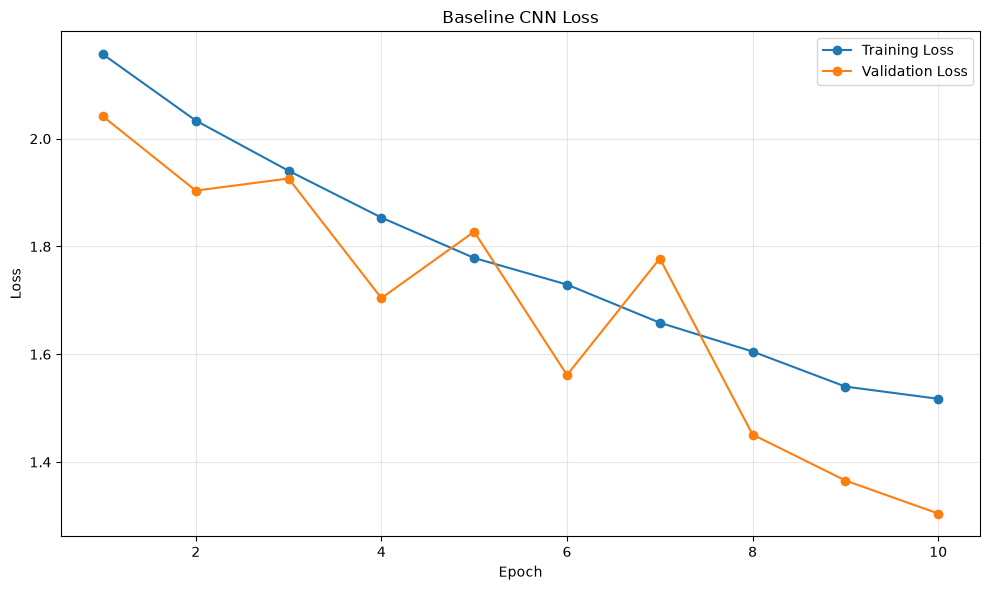

In [26]:
## PLOt model performance
# Plot training and validation loss
plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index,
    history_df["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df.index,
    history_df["validation_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Baseline CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

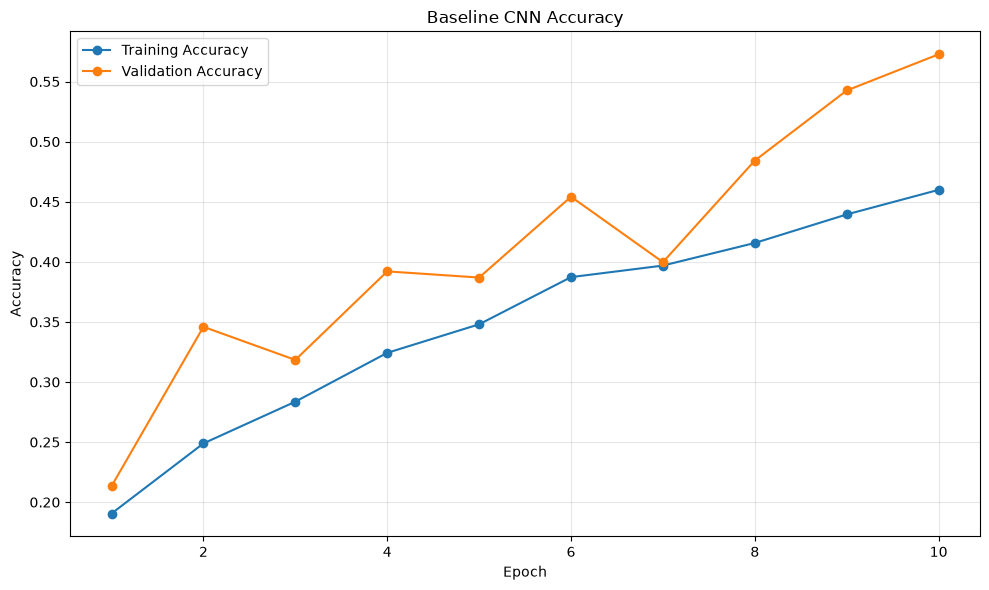

In [27]:
# Plot training and validation accuracy
plt.figure(figsize=(10, 6))

plt.plot(
    history_df.index,
    history_df["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df.index,
    history_df["validation_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Baseline CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# Load the best checkpoint
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
print("Loaded checkpoint from epoch:", checkpoint["epoch"])
print(
    "Best validation accuracy:",
    round(checkpoint["validation_accuracy"], 4)
)


Loaded checkpoint from epoch: 10
Best validation accuracy: 0.5727


In [29]:
# Evaluate on the internal test set
(
    test_loss,
    test_accuracy,
    test_targets,
    test_predictions
) = evaluate_model(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=DEVICE
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 1.2682
Test accuracy: 0.5813


In [30]:
# Generate the classification report
report = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES)),
    target_names=[
        class_name.replace("_","").title()
        for class_name in class_names
    ],
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).transpose()
display(report_df.round(4))

,precision,recall,f1-score,support
Bacterialleafblight,0.2626,0.3611,0.3041,72.0000
Bacterialleafstreak,0.6129,0.6667,0.6387,57.0000
Bacterialpanicleblight,0.6852,0.7400,0.7115,50.0000
Blast,0.8901,0.3103,0.4602,261.0000
Brownspot,0.4375,0.6276,0.5156,145.0000
Deadheart,0.7300,0.8848,0.8000,217.0000
Downymildew,0.3922,0.4301,0.4103,93.0000
Hispa,0.5471,0.5105,0.5281,239.0000
Normal,0.6329,0.8264,0.7169,265.0000
Tungro,0.5439,0.3804,0.4477,163.0000


In [31]:
# Save  the classification report
REPORT_PATH = OUTPUT_DIR / "baseline_classification_report.csv"
report_df.to_csv(REPORT_PATH)
print("Classification report saved to:")
print(REPORT_PATH)

Classification report saved to:
C:\Projects\16_Rice_Guard\outputs\baseline_classification_report.csv


In [33]:
# Create a concise metric summary
baseline_metrics_df = pd.DataFrame([
    {
        "model": "Baseline CNN",
        "best_epoch": checkpoint["epoch"],
        "validation_accuracy": checkpoint["validation_accuracy"],
        "test_loss": test_loss,
        "test_accuracy": test_accuracy,
        "macro_precision": report["macro avg"]["precision"],
        "macro_recall": report["macro avg"]["recall"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "training_minutes": total_training_time / 60
    }
])

BASELINE_METRICS_PATH = OUTPUT_DIR / "baseline_metrics.csv"

baseline_metrics_df.to_csv(
    BASELINE_METRICS_PATH,
    index=False
)

display(baseline_metrics_df.round(4))

,model,best_epoch,validation_accuracy,test_loss,test_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_minutes
0,Baseline CNN,10,0.5727,1.2682,0.5813,0.5734,0.5738,0.5533,0.5696,74.3009


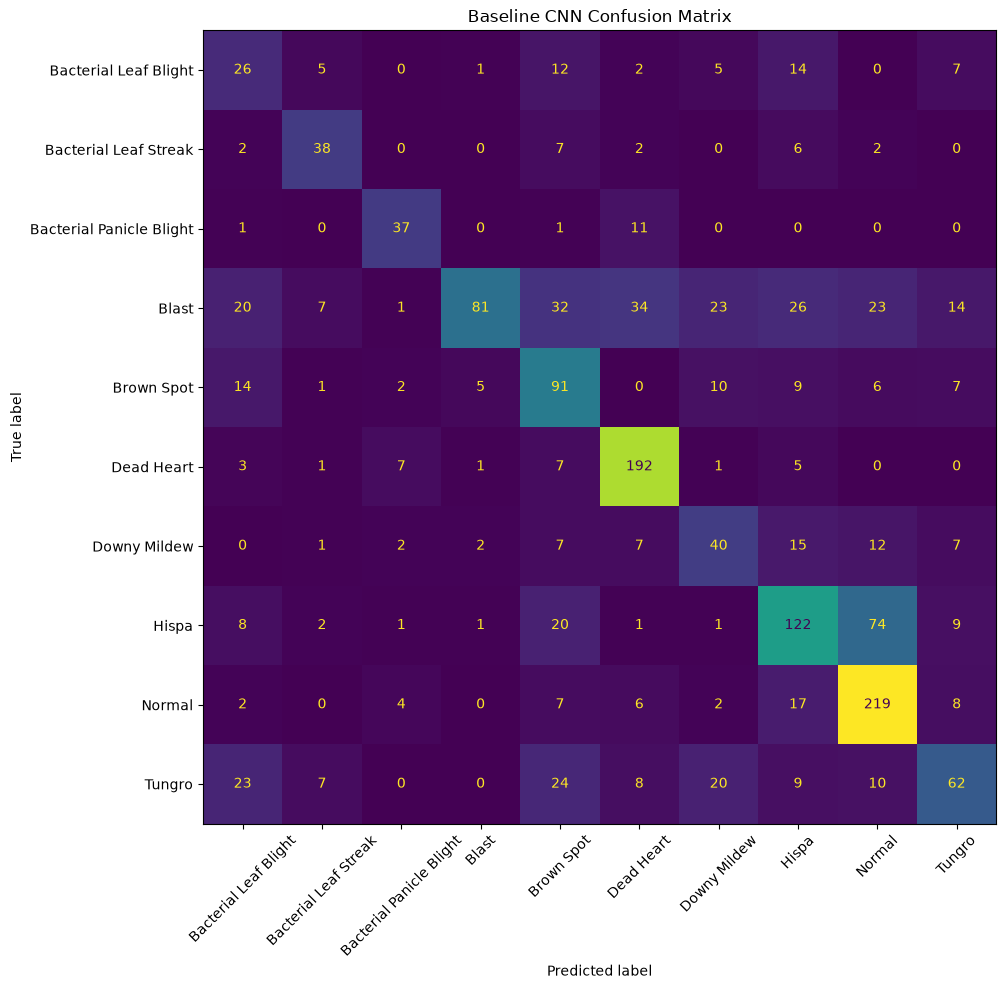

In [39]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

display_names = [
    class_name.replace("_", " ").title()
    for class_name in class_names
]

cm = confusion_matrix(
    test_targets,
    test_predictions,
    labels=list(range(NUM_CLASSES))
)

fig, ax = plt.subplots(figsize=(12, 10))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_names
).plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
    colorbar=False
)

plt.title("Baseline CNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [40]:
# Save individual test predictions
test_results_df = test_df[
    ["image_id", "label", "image_path"]
].copy()

test_results_df["true_target"] = test_targets
test_results_df["predicted_target"] = test_predictions

test_results_df["predicted_label"] = [
    index_to_class[prediction]
    for prediction in test_predictions
]

test_results_df["correct_prediction"] = (
    test_results_df["label"]
    == test_results_df["predicted_label"]
)

TEST_RESULTS_PATH = OUTPUT_DIR / "baseline_test_predictions.csv"

test_results_df.to_csv(
    TEST_RESULTS_PATH,
    index=False
)

display(test_results_df.head())

print("Test predictions saved to:")
print(TEST_RESULTS_PATH)

,image_id,label,image_path,true_target,predicted_target,predicted_label,correct_prediction
0,101970.jpg,dead_heart,C:\Projects\16_Rice_Guard\data\raw\train_image...,5,5,dead_heart,True
1,105763.jpg,brown_spot,C:\Projects\16_Rice_Guard\data\raw\train_image...,4,4,brown_spot,True
2,106689.jpg,tungro,C:\Projects\16_Rice_Guard\data\raw\train_image...,9,4,brown_spot,False
3,103812.jpg,blast,C:\Projects\16_Rice_Guard\data\raw\train_image...,3,7,hispa,False
4,100597.jpg,blast,C:\Projects\16_Rice_Guard\data\raw\train_image...,3,6,downy_mildew,False


Test predictions saved to:
C:\Projects\16_Rice_Guard\outputs\baseline_test_predictions.csv


Incorrect predictions: 654


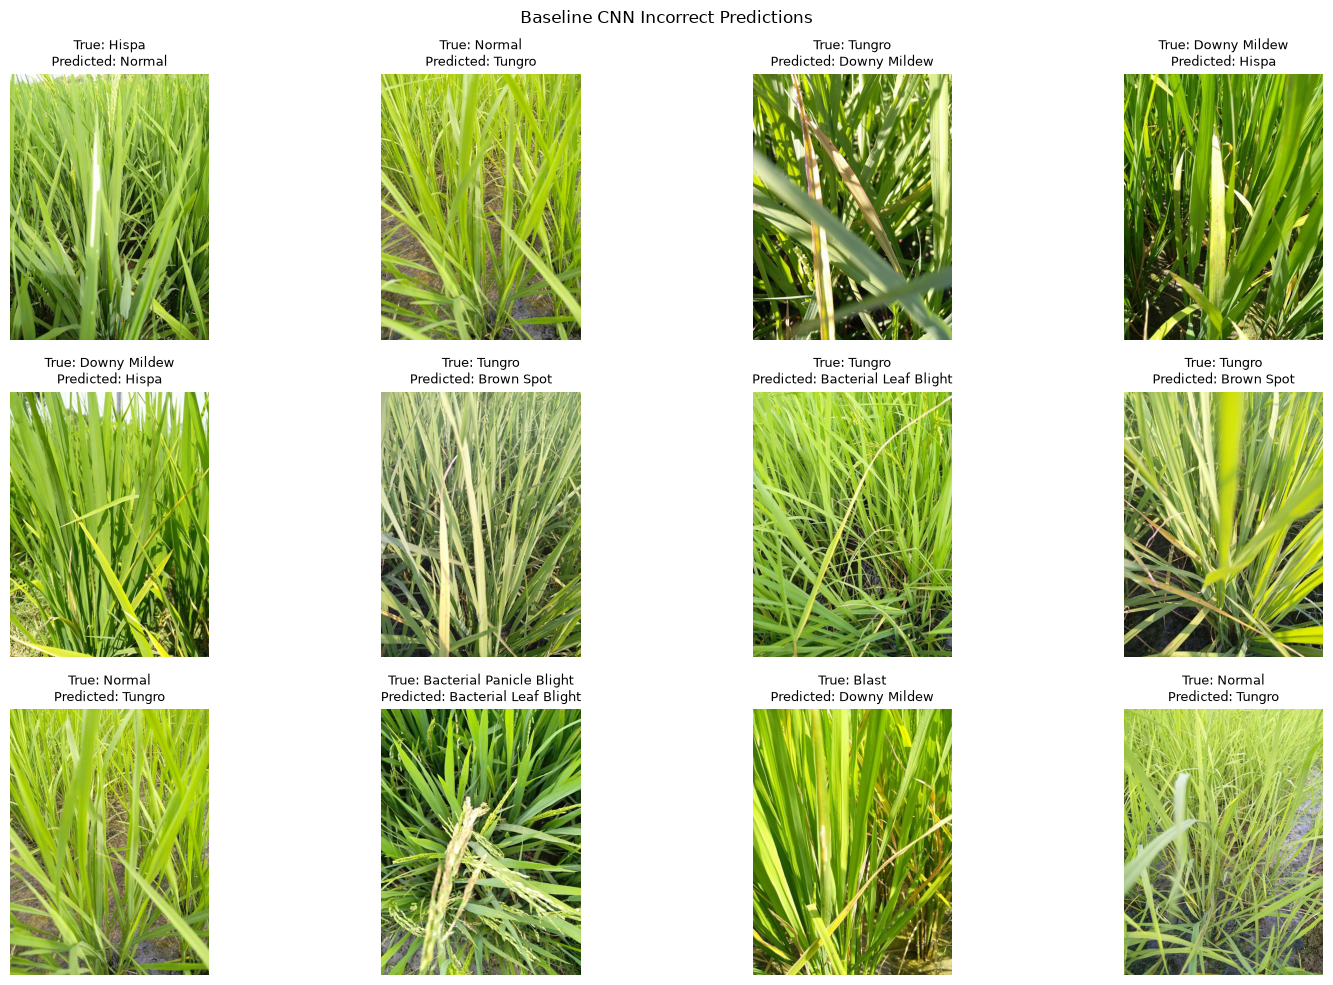

In [41]:
# display some incorrect predictions
incorrect_df = test_results_df[
    ~test_results_df["correct_prediction"]
].copy()

print("Incorrect predictions:", len(incorrect_df))

number_to_display = min(12, len(incorrect_df))

if number_to_display > 0:
    samples = incorrect_df.sample(
        n=number_to_display,
        random_state=42
    )

    plt.figure(figsize=(16, 10))

    for index, (_, row) in enumerate(samples.iterrows()):
        with Image.open(row["image_path"]) as image:
            plt.subplot(3, 4, index + 1)
            plt.imshow(image.convert("RGB"))

        true_name = row["label"].replace("_", " ").title()
        predicted_name = (
            row["predicted_label"]
            .replace("_", " ")
            .title()
        )

        plt.title(
            f"True: {true_name}\n"
            f"Predicted: {predicted_name}",
            fontsize=9
        )

        plt.axis("off")

    plt.suptitle("Baseline CNN Incorrect Predictions")
    plt.tight_layout()
    plt.show()

## Baseline CNN Conclusion

The custom baseline CNN achieved:

- Best epoch: 10
- Best validation accuracy: 57.27%
- Internal test accuracy: 58.13%
- Internal test loss: 1.2682
- Total training time: 74.30 minutes

The model learned useful rice-disease image patterns, but its moderate test accuracy and incorrect predictions show that a CNN trained from scratch has limited feature-extraction capability for this dataset.

This baseline result will be used as a benchmark for comparison with pretrained transfer-learning models.